<a href="https://colab.research.google.com/github/rogon666/UMSA/blob/main/UMSA_2026_001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        count         mean          std          min          25%  \
sex                                                                 
Men    5000.0  5001.098113  1288.212431  1928.636180  4077.011042   
Women  5000.0  2511.048989   626.101752   936.782809  2059.263387   

               50%          75%           max  
sex                                            
Men    4839.324277  5743.069998  13399.429630  
Women  2441.055946  2878.015656   5917.627074  


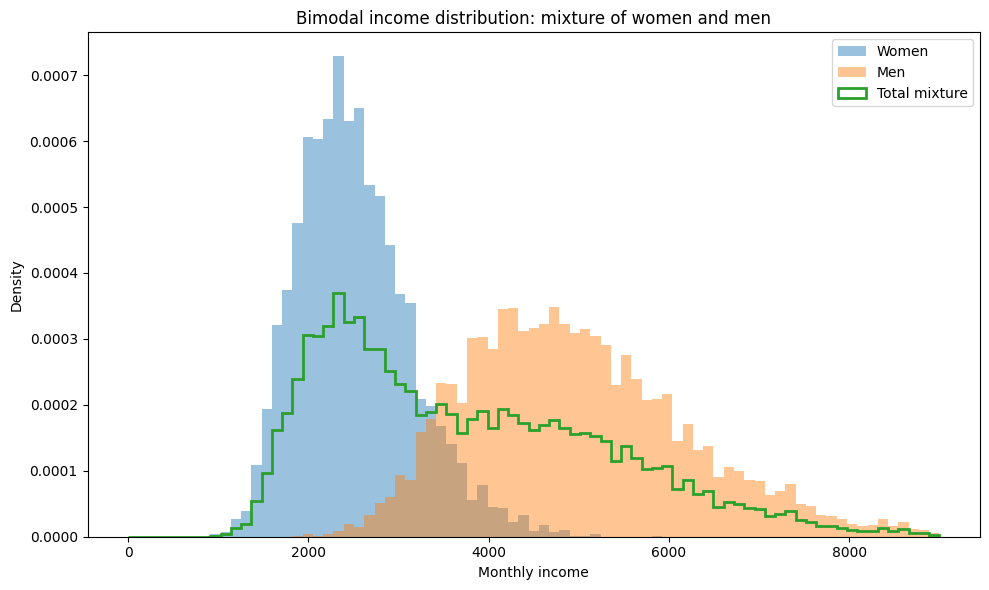

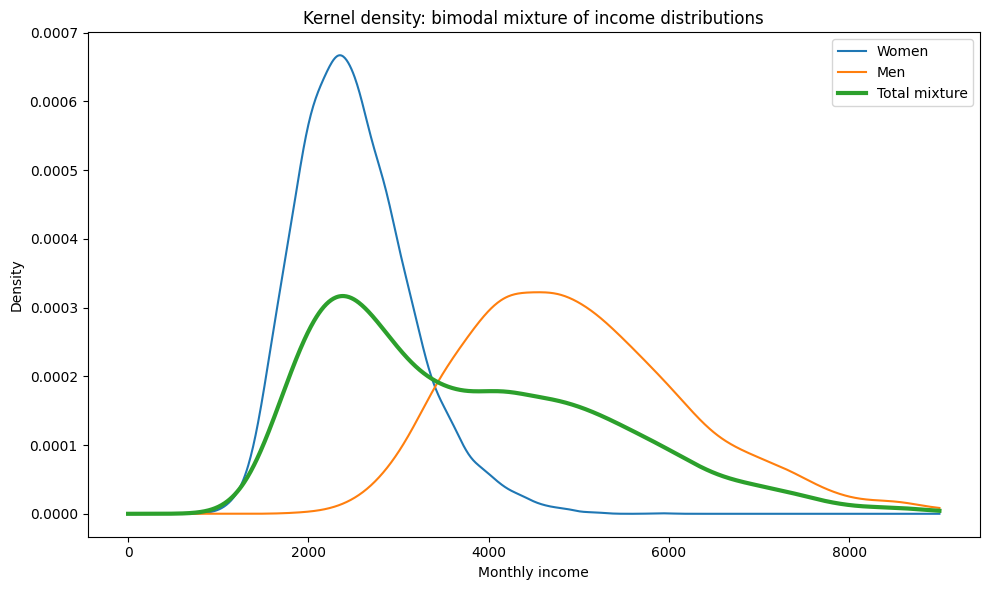

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Simulación de ingresos: mezcla bimodal hombres / mujeres
# ------------------------------------------------------------

np.random.seed(123)

# Tamaño muestral
n_women = 5000
n_men = 5000

# Parámetros deseados en escala monetaria
# Estos valores son ficticios y solo sirven para ilustración.
mean_women = 2500
mean_men = 5000

# Dispersión lognormal
# Valores más bajos hacen que los grupos estén más separados visualmente.
sigma_women = 0.25
sigma_men = 0.25

# Convertir media deseada a parámetro mu de la lognormal
# Si X ~ Lognormal(mu, sigma^2), entonces E[X] = exp(mu + sigma^2 / 2)
mu_women = np.log(mean_women) - 0.5 * sigma_women**2
mu_men = np.log(mean_men) - 0.5 * sigma_men**2

# Generar ingresos
income_women = np.random.lognormal(mean=mu_women, sigma=sigma_women, size=n_women)
income_men = np.random.lognormal(mean=mu_men, sigma=sigma_men, size=n_men)

# Crear base de datos
df = pd.DataFrame({
    "income": np.concatenate([income_women, income_men]),
    "sex": ["Women"] * n_women + ["Men"] * n_men
})

# Estadísticas descriptivas
print(df.groupby("sex")["income"].describe())

# ------------------------------------------------------------
# Gráfico: histogramas por grupo y distribución total
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

bins = np.linspace(0, 9000, 80)

plt.hist(
    income_women,
    bins=bins,
    alpha=0.45,
    density=True,
    label="Women"
)

plt.hist(
    income_men,
    bins=bins,
    alpha=0.45,
    density=True,
    label="Men"
)

plt.hist(
    df["income"],
    bins=bins,
    histtype="step",
    linewidth=2,
    density=True,
    label="Total mixture"
)

plt.xlabel("Monthly income")
plt.ylabel("Density")
plt.title("Bimodal income distribution: mixture of women and men")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Gráfico con densidad kernel de la mezcla total
# ------------------------------------------------------------

x_grid = np.linspace(0, 9000, 1000)

kde_total = gaussian_kde(df["income"])
kde_women = gaussian_kde(income_women)
kde_men = gaussian_kde(income_men)

plt.figure(figsize=(10, 6))

plt.plot(x_grid, kde_women(x_grid), label="Women")
plt.plot(x_grid, kde_men(x_grid), label="Men")
plt.plot(x_grid, kde_total(x_grid), linewidth=3, label="Total mixture")

plt.xlabel("Monthly income")
plt.ylabel("Density")
plt.title("Kernel density: bimodal mixture of income distributions")
plt.legend()
plt.tight_layout()
plt.show()